In [1]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set standard plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# ---------------------------------------------------------
input_pairs = [
    {
        "model_name": "DeepseekV4Flash_Sec",
        "result_file": "result/iacgod/NeoDPIaCEval_TF_DeepseekV4Flash_security_runs.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_TF_Sec.csv"
    }
]

In [9]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    cov_df = pd.read_csv(pair["coverage_file"])

    # Merge based on ground_truth_path (or row_number for legacy CFN)
    merge_key = "ground_truth_path" if "ground_truth_path" in cov_df.columns else "row_number"
    
    cols_to_use = cov_df.columns.difference(res_df.columns).tolist() + [merge_key]
    merged_df = pd.merge(res_df, cov_df[cols_to_use], on=merge_key, how="left")
    merged_dataframes[model] = merged_df

    print(f"✅ Successfully merged {len(merged_df)} rows for {model} (Key: {merge_key}).")

✅ Successfully merged 133 rows for DeepseekV4Flash_Sec (Key: ground_truth_path).


📊 Overall Pass Rates:
  -> DeepseekV4Flash_Sec: 130/133 (97.7%)


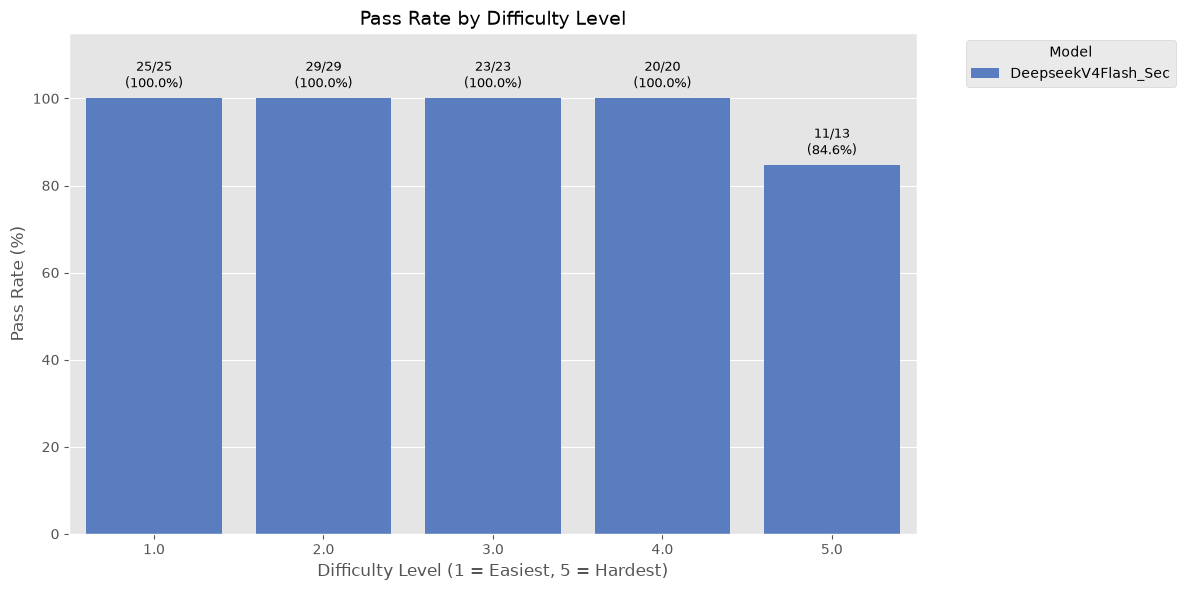

In [15]:
# %%
# ── 1. Pass Rate by Difficulty ────────────────────────────────────────────────
difficulty_stats = []

print("📊 Overall Pass Rates:")
for model_name, df in merged_dataframes.items():
    diff_col = 'difficulty_level' if 'difficulty_level' in df.columns else 'difficulty'
    val_col = 'final_validation_passed' if 'final_validation_passed' in df.columns else ('deploy_pass' if 'deploy_pass' in df.columns else None)

    if diff_col in df.columns and val_col in df.columns:
        # Calculate overall pass rate
        total_passed = int(df[val_col].sum())
        total_scenarios = len(df)
        overall_rate = (total_passed / total_scenarios * 100) if total_scenarios > 0 else 0
        print(f"  -> {model_name}: {total_passed}/{total_scenarios} ({overall_rate:.1f}%)")

        # Calculate pass rate per difficulty
        grouped = df.groupby(diff_col)[val_col].agg(['sum', 'count', 'mean'])
        
        for diff, row in grouped.iterrows():
            passed_cnt = int(row['sum'])
            total_cnt = int(row['count'])
            rate = row['mean'] * 100
            
            difficulty_stats.append({
                'Model': model_name,
                'Difficulty Level': diff,
                'Passed': passed_cnt,
                'Total': total_cnt,
                'Pass Rate (%)': rate
            })

if difficulty_stats:
    diff_df = pd.DataFrame(difficulty_stats)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=diff_df, x='Difficulty Level', y='Pass Rate (%)', hue='Model')
    
    plt.title('Pass Rate by Difficulty Level', fontsize=14)
    plt.ylim(0, 115)  # Increased ylim to accommodate the text labels
    plt.xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
    plt.ylabel('Pass Rate (%)')
    
    # Move legend outside to prevent overlap with text
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add labels to the top of each bar
    for i, container in enumerate(ax.containers):
        # Each container represents a hue (Model)
        model_name = ax.get_legend().get_texts()[i].get_text()
        
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue  # Skip empty bars
                
            # The x-tick label corresponds to the difficulty level
            diff_level = ax.get_xticklabels()[j].get_text()
            
            # Retrieve the exact counts from our dataframe
            row = diff_df[(diff_df['Model'] == model_name) & (diff_df['Difficulty Level'].astype(str) == diff_level)]
            
            if not row.empty:
                passed = row['Passed'].values[0]
                total = row['Total'].values[0]
                rate = row['Pass Rate (%)'].values[0]
                
                label_text = f"{passed}/{total}\n({rate:.1f}%)"
                
                # Annotate the bar
                ax.annotate(label_text, 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', 
                            xytext=(0, 5), textcoords='offset points',
                            fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find difficulty or validation columns to plot Pass Rate.")

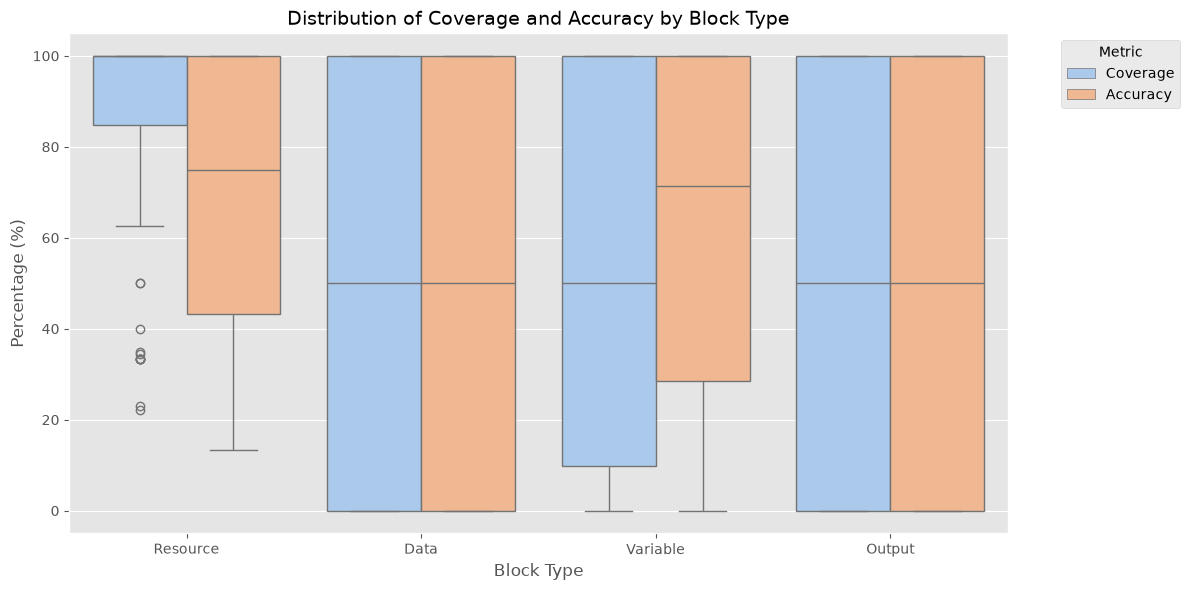

In [11]:
# ── 2. Coverage & Accuracy Distributions by Block Type (Boxplots) ─────────────
box_data = []
block_types = ['resource', 'data', 'variable', 'output']

for model_name, df in merged_dataframes.items():
    # Legacy CFN Support
    if 'coverage_pct' in df.columns:
        for _, row in df.dropna(subset=['coverage_pct', 'accuracy_pct']).iterrows():
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage', 'Percentage': row['coverage_pct']})
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy', 'Percentage': row['accuracy_pct']})
    else:
        # New TF Block Types
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                for _, row in df.dropna(subset=[cov_col, acc_col]).iterrows():
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage', 'Percentage': row[cov_col]})
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy', 'Percentage': row[acc_col]})

if box_data:
    box_df = pd.DataFrame(box_data)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=box_df, x='Block Type', y='Percentage', hue='Metric', palette='pastel')
    plt.title('Distribution of Coverage and Accuracy by Block Type', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.ylim(-5, 105)
    plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

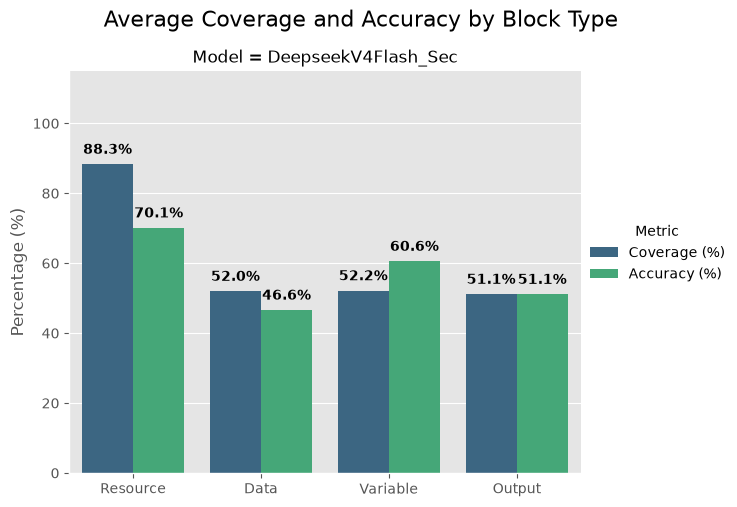

In [12]:
# ── 3. Average Coverage and Accuracy Bar Chart (By Block Type) ────────────────
avg_metrics_data = []

for model_name, df in merged_dataframes.items():
    if 'coverage_pct' in df.columns:
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage (%)', 'Value': df['coverage_pct'].mean()})
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy (%)', 'Value': df['accuracy_pct'].mean()})
    else:
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage (%)', 'Value': df[cov_col].mean()})
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy (%)', 'Value': df[acc_col].mean()})

if avg_metrics_data:
    avg_df = pd.DataFrame(avg_metrics_data)
    
    # Use catplot to handle single or multiple models elegantly
    g = sns.catplot(
        data=avg_df, kind="bar",
        x="Block Type", y="Value", hue="Metric", col="Model",
        palette="viridis", height=5, aspect=1.2
    )
    
    g.set_axis_labels("", "Percentage (%)")
    g.set(ylim=(0, 115))
    g.fig.suptitle('Average Coverage and Accuracy by Block Type', fontsize=16, y=1.05)

    # Add data labels to bars
    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
    plt.show()

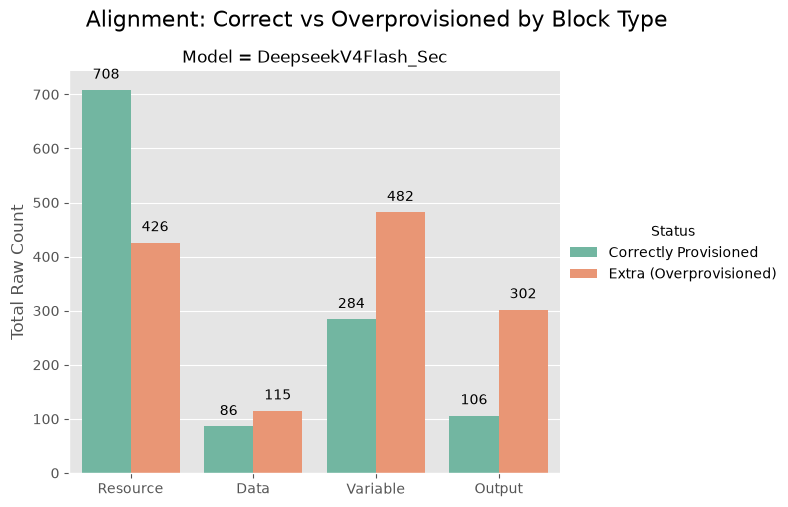

In [13]:
# ── 4. Resource Alignment: Correct vs Overprovisioned (By Block Type) ─────────
overprovisioning_data = []

for model_name, df in merged_dataframes.items():
    if 'correct_resources' in df.columns:
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Correctly Provisioned', 'Total': df['correct_resources'].sum()})
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Extra (Overprovisioned)', 'Total': df['extra_resources'].sum()})
    else:
        for btype in block_types:
            cor_col, ext_col = f'{btype}_cor', f'{btype}_extra'
            if cor_col in df.columns and ext_col in df.columns:
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Correctly Provisioned', 'Total': df[cor_col].sum()})
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Extra (Overprovisioned)', 'Total': df[ext_col].sum()})

if overprovisioning_data:
    over_df = pd.DataFrame(overprovisioning_data)
    
    g = sns.catplot(
        data=over_df, kind="bar",
        x="Block Type", y="Total", hue="Status", col="Model",
        palette="Set2", height=5, aspect=1.2, sharey=False
    )
    
    g.set_axis_labels("", "Total Raw Count")
    g.fig.suptitle('Alignment: Correct vs Overprovisioned by Block Type', fontsize=16, y=1.05)

    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + (ax.get_ylim()[1] * 0.02), f'{int(height)}', ha='center', va='bottom', fontsize=10)
                
    plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_62082/257090815.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


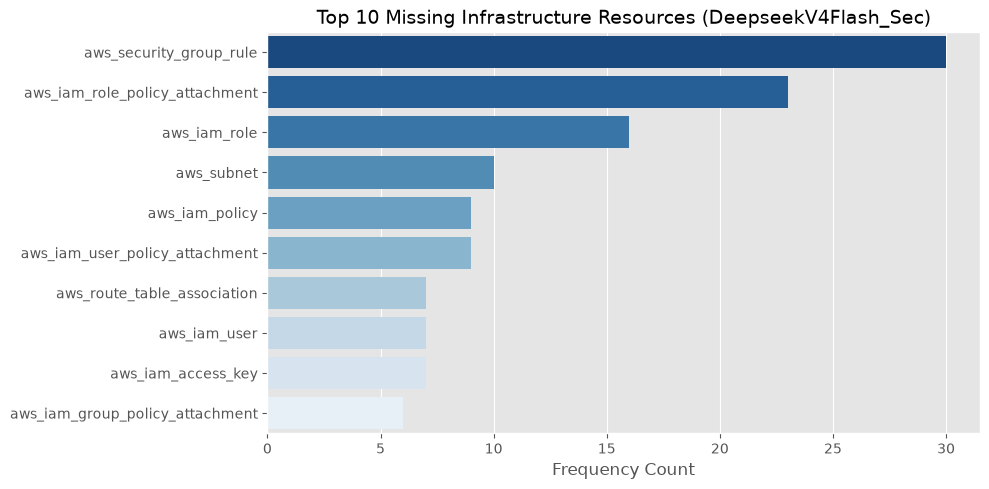

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_62082/257090815.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


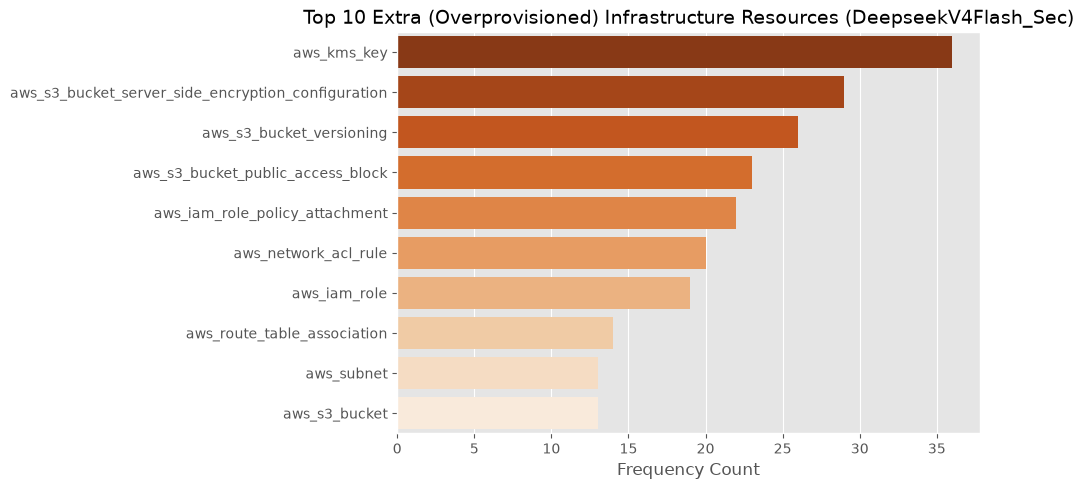

In [14]:
# ── 5. Top Missing and Extra Resource Types ───────────────────────────────────
# Note: We only plot "Resource" types here as variables and outputs usually have 
# arbitrary user-defined names that aren't useful to aggregate in a bar chart.

for model_name, df in merged_dataframes.items():
    missing_counter = Counter()
    extra_counter = Counter()

    missing_col = 'resource_missing_list' if 'resource_missing_list' in df.columns else 'missing_resource_types'
    extra_col = 'resource_extra_list' if 'resource_extra_list' in df.columns else 'extra_resource_types'

    if missing_col in df.columns:
        for items in df[missing_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    missing_counter[item.strip()] += 1

    if extra_col in df.columns:
        for items in df[extra_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    extra_counter[item.strip()] += 1

    top_missing = pd.DataFrame(missing_counter.most_common(10), columns=['Resource Type', 'Frequency'])
    top_extra = pd.DataFrame(extra_counter.most_common(10), columns=['Resource Type', 'Frequency'])

    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')
        plt.title(f'Top 10 Missing Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

    if not top_extra.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')
        plt.title(f'Top 10 Extra (Overprovisioned) Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()